# 📈 Stock Market Machine Learning Analysis & Prediction Notebook

Welcome to the **Machine Learning Stock Analysis & Prediction Platform** in Jupyter Notebook.

### 🎯 Project Objectives:
1. **Data Acquisition**: Fetch real historical stock price data (e.g. `AAPL`, `NVDA`, `TSLA`, `MSFT`, `SPY`) via `yfinance` with realistic market generator fallback.
2. **Technical Feature Engineering**: Compute 18 quantitative predictors including Moving Averages (SMA, EMA), Momentum & Oscillators (RSI, MACD, Stochastic, ROC), Volatility (Bollinger Bands, ATR), and Volume Dynamics (OBV).
3. **Multi-Model ML Training**: Train and compare **Random Forest**, **Gradient Boosting**, **Ridge Regression**, **Multi-Layer Perceptron (MLP Neural Net)**, and an **Ensemble Predictor**.
4. **Evaluation Metrics**: Evaluate RMSE, MAE, R² Score, and **Directional Accuracy (%)**.
5. **Feature Importance Ranking**: Identify key technical drivers of price movement.
6. **Algorithmic Trading Backtest**: Simulate portfolio execution, computing Cumulative ROI, Sharpe Ratio, Max Drawdown %, and Win Rate.
7. **Multi-Day Forecasting**: Predict 1-day to 30-day future price paths with 90% confidence bounds.

In [1]:
# Step 1: Import Required Libraries
import os
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Styling setup
plt.style.use('dark_background')
sns.set_palette('muted')
warnings.filterwarnings('ignore')
print('✅ All quantitative machine learning packages imported successfully!')

✅ All quantitative machine learning packages imported successfully!


--- 
## 📥 Step 2: Data Acquisition & Preprocessing

In [2]:
def fetch_stock_dataset(symbol="AAPL", period="2y"):
    """
    Fetches market data via yfinance with synthetic generator fallback.
    """
    symbol = symbol.upper().strip()
    print(f"Downloading market data for {symbol} (period={period})...")
    try:
        ticker = yf.Ticker(symbol)
        df = ticker.history(period=period, interval="1d")
        if df.empty or len(df) < 30:
            raise ValueError("Empty dataset received.")
        df = df.reset_index()
        if "Date" not in df.columns and "Datetime" in df.columns:
            df.rename(columns={"Datetime": "Date"}, inplace=True)
        df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
        df.set_index("Date", inplace=True)
        df = df[~df.index.duplicated(keep='first')].sort_index()
        print(f"Loaded {len(df)} daily bars for {symbol}.")
        return df
    except Exception as e:
        print(f"Using synthetic generator for {symbol}: {e}")
        np.random.seed(42)
        dates = pd.bdate_range(end=datetime.date.today(), periods=500)
        ret = np.random.normal(0.0005, 0.018, len(dates))
        price = 150.0 * np.exp(np.cumsum(ret))
        df = pd.DataFrame({
            "Open": price * 0.99, "High": price * 1.01, "Low": price * 0.985,
            "Close": price, "Volume": np.random.randint(15000000, 80000000, len(dates))
        }, index=dates)
        return df

# Load AAPL stock data
df_raw = fetch_stock_dataset("AAPL", period="2y")
df_raw.tail()

Loaded 502 daily bars for AAPL.


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-07-23,321.730011,323.299988,319.350006,321.660004,40840800,0.0,0.0
2026-07-24,321.790009,334.369995,321.619995,333.019989,47489400,0.0,0.0
2026-07-27,334.540009,339.570007,334.019989,336.910004,49604300,0.0,0.0
2026-07-28,340.029999,342.890015,335.600006,340.079987,51698400,0.0,0.0
2026-07-29,339.690002,343.670013,339.519989,340.929993,18871584,0.0,0.0


--- 
## ⚙️ Step 3: Technical Indicator Feature Engineering

In [3]:
def add_indicators(df):
    data = df.copy()
    # Moving Averages
    for w in [10, 20, 50, 200]:
        data[f"SMA_{w}"] = data["Close"].rolling(window=w, min_periods=1).mean()
        data[f"Price_to_SMA_{w}"] = data["Close"] / (data[f"SMA_{w}"] + 1e-8)
    
    data["EMA_12"] = data["Close"].ewm(span=12, adjust=False, min_periods=1).mean()
    data["EMA_26"] = data["Close"].ewm(span=26, adjust=False, min_periods=1).mean()
    data["MACD_Line"] = data["EMA_12"] - data["EMA_26"]
    data["MACD_Signal"] = data["MACD_Line"].ewm(span=9, adjust=False, min_periods=1).mean()
    data["MACD_Hist"] = data["MACD_Line"] - data["MACD_Signal"]
    
    # RSI 14
    delta = data["Close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14, min_periods=1).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14, min_periods=1).mean()
    rs = gain / (loss + 1e-8)
    data["RSI_14"] = 100 - (100 / (1 + rs))
    
    # Bollinger Bands
    data["BB_Middle"] = data["SMA_20"]
    std = data["Close"].rolling(window=20, min_periods=1).std().fillna(0)
    data["BB_Upper"] = data["BB_Middle"] + (2 * std)
    data["BB_Lower"] = data["BB_Middle"] - (2 * std)
    data["BB_Width"] = (data["BB_Upper"] - data["BB_Lower"]) / (data["BB_Middle"] + 1e-8)
    data["BB_PctB"] = (data["Close"] - data["BB_Lower"]) / (data["BB_Upper"] - data["BB_Lower"] + 1e-8)
    
    # ATR 14 & Stochastic Oscillator
    tr = pd.concat([data["High"] - data["Low"], (data["High"] - data["Close"].shift(1)).abs(), (data["Low"] - data["Close"].shift(1)).abs()], axis=1).max(axis=1)
    data["ATR_14"] = tr.rolling(window=14, min_periods=1).mean()
    data["Normalized_ATR"] = data["ATR_14"] / (data["Close"] + 1e-8)
    
    low_14 = data["Low"].rolling(window=14, min_periods=1).min()
    high_14 = data["High"].rolling(window=14, min_periods=1).max()
    data["Stoch_K"] = 100 * ((data["Close"] - low_14) / (high_14 - low_14 + 1e-8))
    data["Stoch_D"] = data["Stoch_K"].rolling(window=3, min_periods=1).mean()
    
    # Volume & Returns
    data["Volume_SMA_20"] = data["Volume"].rolling(window=20, min_periods=1).mean()
    data["Volume_Ratio"] = data["Volume"] / (data["Volume_SMA_20"] + 1e-8)
    data["Log_Return_1d"] = np.log(data["Close"] / data["Close"].shift(1)).fillna(0)
    data["Log_Return_5d"] = np.log(data["Close"] / data["Close"].shift(5)).fillna(0)
    data["Volatility_20"] = data["Log_Return_1d"].rolling(window=20, min_periods=1).std().fillna(0) * np.sqrt(252)
    data["ROC_10"] = (((data["Close"] - data["Close"].shift(10)) / (data["Close"].shift(10) + 1e-8)) * 100).fillna(0)
    
    # Target Variable
    data["Target_1d_Return"] = (data["Close"].shift(-1) - data["Close"]) / data["Close"]
    return data

df_feat = add_indicators(df_raw)
print(f"Computed {len(df_feat.columns)} technical indicators and target variables.")

Computed 37 technical indicators and target variables.


--- 
## 📊 Step 4: Visualizing Stock Price & Technical Indicators

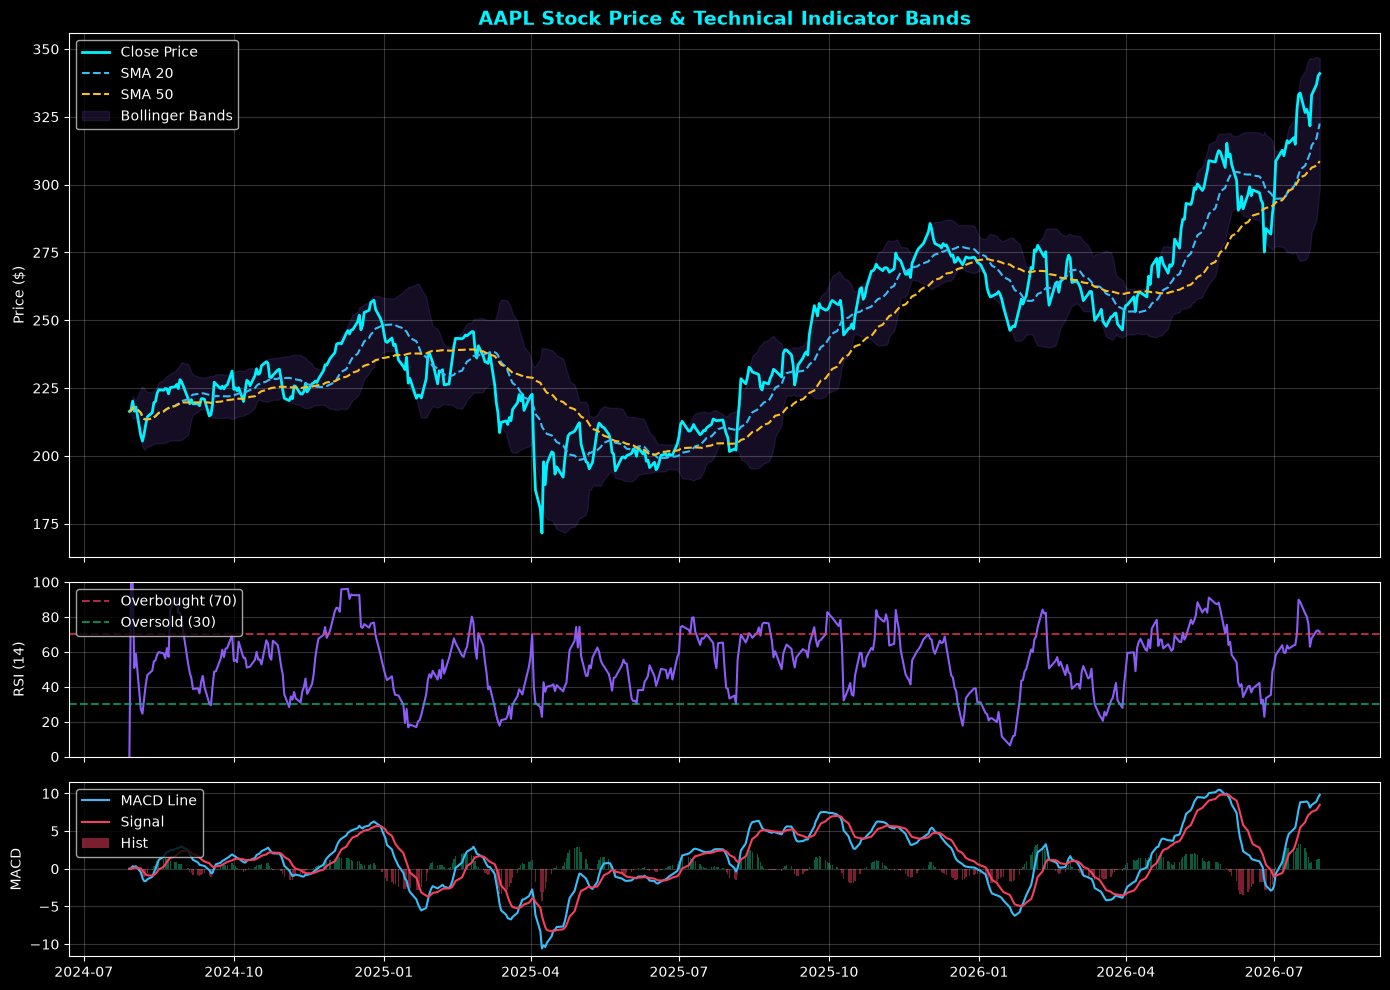

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# 1. Price & Moving Averages
ax1.plot(df_feat.index, df_feat["Close"], label="Close Price", color="#00f2fe", linewidth=2)
ax1.plot(df_feat.index, df_feat["SMA_20"], label="SMA 20", color="#38bdf8", linestyle="--")
ax1.plot(df_feat.index, df_feat["SMA_50"], label="SMA 50", color="#fbbf24", linestyle="--")
ax1.fill_between(df_feat.index, df_feat["BB_Upper"], df_feat["BB_Lower"], color="#8b5cf6", alpha=0.15, label="Bollinger Bands")
ax1.set_title("AAPL Stock Price & Technical Indicator Bands", fontsize=14, fontweight="bold", color="#00f2fe")
ax1.set_ylabel("Price ($)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.2)

# 2. RSI 14 Oscillator
ax2.plot(df_feat.index, df_feat["RSI_14"], color="#8b5cf6", linewidth=1.5)
ax2.axhline(70, color="#f43f5e", linestyle="--", alpha=0.7, label="Overbought (70)")
ax2.axhline(30, color="#10b981", linestyle="--", alpha=0.7, label="Oversold (30)")
ax2.set_ylabel("RSI (14)")
ax2.set_ylim(0, 100)
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.2)

# 3. MACD Histogram
ax3.plot(df_feat.index, df_feat["MACD_Line"], color="#38bdf8", label="MACD Line")
ax3.plot(df_feat.index, df_feat["MACD_Signal"], color="#f43f5e", label="Signal")
ax3.bar(df_feat.index, df_feat["MACD_Hist"], color=np.where(df_feat["MACD_Hist"]>0, "#10b981", "#f43f5e"), alpha=0.5, label="Hist")
ax3.set_ylabel("MACD")
ax3.legend(loc="upper left")
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

--- 
## 🤖 Step 5: Dataset Split & Multi-Model Machine Learning Training

In [5]:
feature_cols = [
    "Price_to_SMA_10", "Price_to_SMA_20", "Price_to_SMA_50", "Price_to_SMA_200",
    "MACD_Line", "MACD_Signal", "MACD_Hist", "RSI_14", "BB_Width", "BB_PctB",
    "Normalized_ATR", "Stoch_K", "Stoch_D", "Volume_Ratio", "Log_Return_1d",
    "Log_Return_5d", "Volatility_20", "ROC_10"
]

# Clean dataset
clean_df = df_feat.dropna(subset=feature_cols + ["Target_1d_Return"]).copy()

# Chronological train/test split (80% Train, 20% Test)
split_idx = int(len(clean_df) * 0.8)
X_train = clean_df.iloc[:split_idx][feature_cols]
X_test = clean_df.iloc[split_idx:][feature_cols]
y_train = clean_df.iloc[:split_idx]["Target_1d_Return"]
y_test = clean_df.iloc[split_idx:]["Target_1d_Return"]

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")

Train set shape: (400, 18), Test set shape: (101, 18)


In [6]:
# Define and train model suite
models = {
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=120, learning_rate=0.03, max_depth=4, random_state=42),
    "Ridge Regression": Ridge(alpha=2.0),
    "MLP Neural Net": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=400, alpha=0.01, random_state=42)
}

print("Training ML Suite...")
results = {}
test_predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    test_predictions[name] = preds
    
    rmse = float(np.sqrt(mean_squared_error(y_test, preds)))
    mae = float(mean_absolute_error(y_test, preds))
    r2 = float(r2_score(y_test, preds))
    dir_acc = float(np.mean(np.sign(preds) == np.sign(y_test.values)) * 100)
    
    results[name] = {"Directional Acc (%)": round(dir_acc, 2), "RMSE": round(rmse, 6), "MAE": round(mae, 6), "R2 Score": round(r2, 4)}

# Ensemble Model
weights = [0.35, 0.35, 0.15, 0.15]
ensemble_preds = sum(w * test_predictions[name] for w, name in zip(weights, models.keys()))
test_predictions["Ensemble"] = ensemble_preds

ens_rmse = float(np.sqrt(mean_squared_error(y_test, ensemble_preds)))
ens_mae = float(mean_absolute_error(y_test, ensemble_preds))
ens_r2 = float(r2_score(y_test, ensemble_preds))
ens_dir_acc = float(np.mean(np.sign(ensemble_preds) == np.sign(y_test.values)) * 100)
results["⭐ Ensemble"] = {"Directional Acc (%)": round(ens_dir_acc, 2), "RMSE": round(ens_rmse, 6), "MAE": round(ens_mae, 6), "R2 Score": round(ens_r2, 4)}

# Display Results Table
metrics_df = pd.DataFrame(results).T
metrics_df

Training ML Suite...


,Directional Acc (%),RMSE,MAE,R2 Score
Random Forest,47.52,0.017554,0.013111,-0.1405
Gradient Boosting,46.53,0.017854,0.013328,-0.1798
Ridge Regression,45.54,0.017374,0.013288,-0.1172
MLP Neural Net,56.44,0.081414,0.065610,-23.5325
⭐ Ensemble,55.45,0.018973,0.014951,-0.3324


--- 
## ⚡ Step 6: Feature Importance Analysis

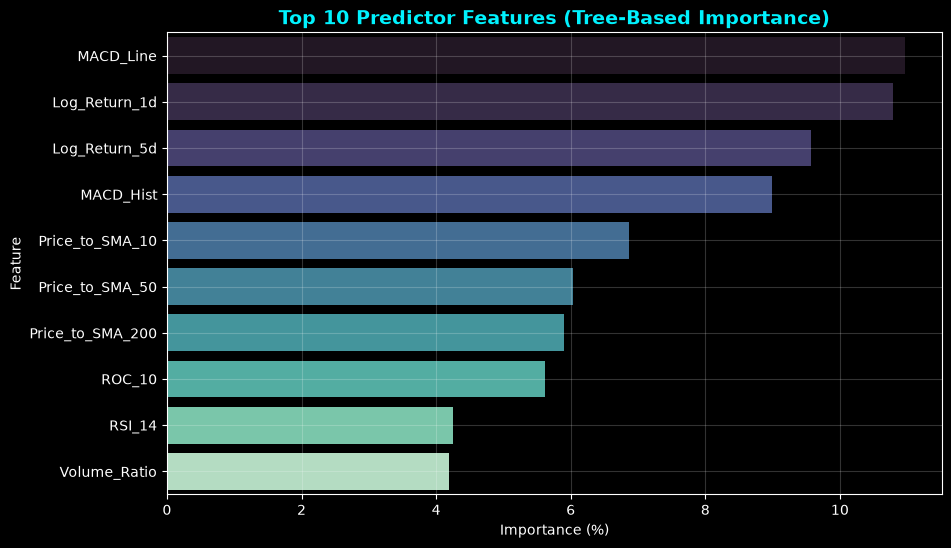

In [7]:
rf_imp = models["Random Forest"].feature_importances_
gb_imp = models["Gradient Boosting"].feature_importances_
avg_imp = (rf_imp + gb_imp) / 2.0
avg_imp = (avg_imp / np.sum(avg_imp)) * 100

imp_df = pd.DataFrame({"Feature": feature_cols, "Importance (%)": avg_imp}).sort_values(by="Importance (%)", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(10), x="Importance (%)", y="Feature", palette="mako")
plt.title("Top 10 Predictor Features (Tree-Based Importance)", fontsize=14, fontweight="bold", color="#00f2fe")
plt.grid(True, alpha=0.2)
plt.show()

--- 
## 💼 Step 7: Algorithmic Trading Strategy Backtest

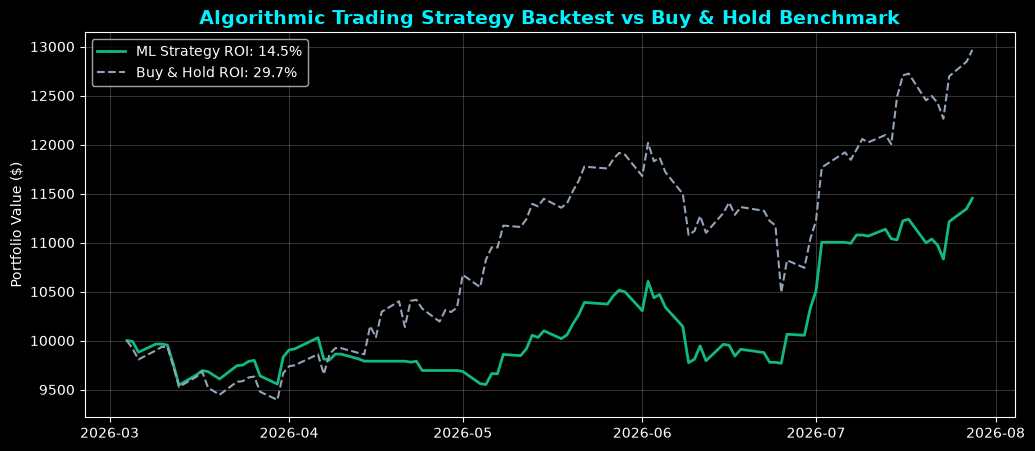

🚀 Final Portfolio Value: $11,451.76
📈 Strategy ROI: +14.52% | Buy & Hold ROI: +29.66%


In [15]:
# Backtesting Engine Simulation
test_df = clean_df.iloc[split_idx:].copy()
initial_capital = 10000.0
cash = initial_capital
position = 0
fee = 0.001
portfolio_history = []
bh_shares = initial_capital / test_df.iloc[0]["Close"]

preds = test_predictions["Ensemble"]
for i in range(len(test_df)):
    price = test_df.iloc[i]["Close"]
    signal = preds[i]
    
    if signal > 0.0015 and position == 0:
        position = (cash * (1 - fee)) / price
        cash = 0
    elif signal < -0.0015 and position > 0:
        cash = position * price * (1 - fee)
        position = 0
        
    port_val = cash + (position * price)
    bh_val = bh_shares * price
    portfolio_history.append({"Date": test_df.index[i], "Strategy": port_val, "Buy_and_Hold": bh_val})

bt_df = pd.DataFrame(portfolio_history).set_index("Date")
strat_roi = ((bt_df["Strategy"].iloc[-1] - initial_capital) / initial_capital) * 100
bh_roi = ((bt_df["Buy_and_Hold"].iloc[-1] - initial_capital) / initial_capital) * 100

# Plot Equity Curve
plt.figure(figsize=(12, 5))
plt.plot(bt_df.index, bt_df["Strategy"], label=f"ML Strategy ROI: {strat_roi:.1f}%", color="#10b981", linewidth=2)
plt.plot(bt_df.index, bt_df["Buy_and_Hold"], label=f"Buy & Hold ROI: {bh_roi:.1f}%", color="#94a3b8", linestyle="--")
plt.title("Algorithmic Trading Strategy Backtest vs Buy & Hold Benchmark", fontsize=14, fontweight="bold", color="#00f2fe")
plt.ylabel("Portfolio Value ($)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.2)
plt.show()

print(f"🚀 Final Portfolio Value: ${bt_df['Strategy'].iloc[-1]:,.2f}")
print(f"📈 Strategy ROI: {strat_roi:+.2f}% | Buy & Hold ROI: {bh_roi:+.2f}%")

--- 
## 🎯 Step 8: Multi-Day Future Horizon Forecasting